# Trabalho 1 (T1) - Análise de consumo de energia/PLD no mercado Brasileiro	1

<span style="color:blue">Integrante 1: João Pedro Muffato Nascimento 	         190900025(140900025?)</span>

<span style="color:green">Integrante 2: Diego Gomes Machado                      190950043</span>

<span style="color:red">Integrante 3: Vinicius Raimundo Pires                    190950026</span>

<span style="color:green">Repositório do Grupo: [Link do GitHub](https://www.google.com) Contendo o ambiente usado,</span> <span style="color:blue">apresentação</span> e <span style="color:green">este relatório</span>

## 1. Introdução e Justificativa
<span style="color:blue">
O Sistema Elétrico Brasileiro opera de forma integrada por meio do Sistema Interligado Nacional (SIN), que conecta usinas de geração aos centros de consumo em quase todo o território nacional. Devido à predominância da matriz hidrelétrica, o custo da energia é altamente volátil, variando conforme a disponibilidade de água nos reservatórios e a necessidade de acionamento de usinas térmicas, que possuem custo de operação mais elevado.
Nesse cenário, o Preço de Liquidação das Diferenças (PLD) atua como o principal indicador de preço do mercado de energia de curto prazo. Ele é calculado pela Câmara de Comercialização de Energia Elétrica (CCEE) com base no Custo Marginal de Operação (CMO) e reflete o equilíbrio entre a oferta e a demanda, além das condições climáticas.
Justificativa da Análise: A escolha desta base de dados justifica-se pela necessidade de compreender a dinâmica econômica do setor. Pretendemos analisar a correlação entre o consumo de energia e o PLD, investigando se as variações de preço influenciam o comportamento de consumo ou se o aumento da demanda em horários de pico é o principal vetor de elevação do preço. Essa análise é fundamental para estratégias de gestão energética e eficiência operacional em engenharia.

Referência da Base de Dados
Curva de carga horária 2025: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/curva-carga-ho/CURVA_CARGA_2025.xlsx

PLD Horário 2025: https://dadosabertos.ccee.org.br/dataset/pld_horario
</span>

## 2. Descrição dos Dados	
<span style="color:blue">Apresentamos aqui as variáveis presentes no conjunto de dados, suas unidades de medida e o que representam fisicamente. Elas estão separadas por natureza do seu conteúdo, sendo dados de index e classe, dados a serem analisados e dados comerciais.</span>

### 2.1. Variáveis de Identificação e Tempo
#### <span style="color:red">Tabela de Definição de Variáveis</span>

| Variável | Descrição | Tipo de Dado |
| :--- | :--- | :--- |
| **Regioes** | Sigla da região/subsistema (N, NE, S, SE). | String |
| **SUBMERCADO** | Nome por extenso da região (NORTE, NORDESTE, SUL, SUDESTE). | String |
| **Data** | Instante exato do registo (formato YYYY-MM-DD HH:MM:SS). | Datetime |
| **Mes** | Mês do ano extraído da coluna Data. | Inteiro (1-12) |
| **DIA** | Dia do mês extraído da coluna Data. | Inteiro (1-31) |
| **HORA** | Hora do dia extraída da coluna Data. | Inteiro (0-23) |
| **MES_REFERENCIA** | Mês de referência do PLD (formato YYYYMM). | Inteiro |



### 2.2 Variáveis de Carga e Potência

<span style="color:red">Dados relativos ao consumo e demanda de energia.</span>

#### Tabela de Variáveis de Carga e Potência

| Variável | Descrição | Unidade / Formato |
| :--- | :--- | :--- |
| **Carga** | Valor da carga de energia (original do dataset). | MWh (Megawatt-hora) |
| **Carga_MW** | Carga convertida (Carga / 1.000.000). | MW (Megawatts) |
| **Carga_KW** | Carga convertida (Carga / 1.000). | kW (Kilowatts) |

### 2.3 Variáveis Financeiras e Comerciais

<span style="color:red">Dados relativos ao custo e preço da energia no mercado.</span>

#### Tabela de Variáveis Financeiras e Comerciais

| Variável | Descrição | Unidade / Formato |
| :--- | :--- | :--- |
| **PLD_HORA** | Preço de Liquidação das Diferenças horário. | R$/MWh |
| **Custos_Milhoes** | Custo total estimado (Carga * PLD_HORA / 1e6). | Milhões de Reais (R$) |
| **PERIODO_COMERCIALIZACAO** | Identificador do período dentro do mês. | Inteiro |

## 3. Limitações e Desafios
<span style="color:blue">

Nesta etapa inicial de desenvolvimento, a origem e a confiabilidade dos dados não representaram obstáculos significativos, visto que as bases utilizadas provêm de órgãos oficiais e apresentam alto grau de integridade. Contudo, o grupo enfrentou desafios técnicos e analíticos relevantes para a viabilização do estudo:
* **Organização e Sincronização de Datasets (Data Merging)**: O principal desafio técnico residiu na harmonização das duas bases de dados (Consumo e PLD). Como os datasets possuem frequências de medição e estruturas distintas, foi necessário aplicar a técnica de merge para unificar as informações. Este processo exigiu um tratamento rigoroso para garantir o alinhamento dos índices temporais, assegurando que cada registro de demanda estivesse corretamente pareado ao preço de liquidação correspondente.
* **Filtragem e Limpeza de Dados**: Houve a necessidade de implementar filtros para lidar com granularidades diferentes e garantir que a base resultante fosse consistente. A limpeza dos dados foi fundamental para evitar que janelas temporais sem registros comprometessem a integridade da análise estatística.
* **Interpretação de Resultados e Gráficos**: Enfrentamos dificuldades na interpretação das informações contidas em ambos os datasets. A extração de insights a partir dos gráficos gerados exigiu uma análise aprofundada para distinguir correlações reais de meras flutuações estatísticas, especialmente ao tentar entender como o comportamento da carga impacta ou é impactado pela volatilidade do PLD.
* **Variáveis Exógenas e Complexidade do Mercado**: Identificamos que o PLD é influenciado por fatores que não estão presentes nos datasets de consumo, como níveis de reservatórios, condições climáticas e despacho térmico. A ausência dessas variáveis limita a capacidade de explicar variações bruscas de preço exclusivamente através da demanda, configurando um desafio para a modelagem futura.
* **Tratamento de Outliers**: A presença de picos atípicos tanto no consumo quanto no preço exigiu critérios de filtragem específicos para evitar que leituras anômalas distorcessem as medidas de tendência central e a análise de correlação do projeto.
</span>

## 4. Análise Estatística Descritiva

### 4.1. Análise dos Resultados da Curva de Carga	
#### <span style="color:red"> Resumo Estatístico - Carga de Energia (MWh)</span>

| Estatística | Valor |
| :--- | ---: |
| **Contagem de dados (count)** | 35.040,00 |
| **Média (mean)** | 19.902,23 |
| **Desvio Padrão (std)** | 14.632,16 |
| **Mínimo (min)** | 6.015,88 |
| **25% (1º Quartil)** | 9.502,21 |
| **50% (Mediana)** | 13.515,30 |
| **75% (3º Quartil)** | 24.450,97 |
| **Máximo (max)** | 62.149,89 |

<span style="color:blue">

A análise descritiva dos dados de carga revela um perfil de consumo com características marcantes de variabilidade e assimetria, fundamentais para entender a dinâmica do setor elétrico no período analisado:
* **Contagem e Integridade**: O total de 35.040 registros confirma a solidez da base de dados. Este volume de dados é estatisticamente significativo, cobrindo um ciclo temporal completo que permite captar sazonalidades importantes.
* **Tendência Central e Assimetria**: A média de 19.902,23 situa-se consideravelmente acima da mediana (13.515,30). Esse distanciamento indica uma assimetria à direita (positiva), revelando que, embora o sistema opere na maior parte do tempo em patamares mais baixos, ele é frequentemente impactado por picos de demanda elevados que deslocam a média para cima.
* **Dispersão e Volatilidade**: O desvio padrão de 14.632,16 representa cerca de 73% do valor da média. Essa alta dispersão confirma uma volatilidade acentuada na carga, sugerindo que o sistema enfrenta variações bruscas de demanda, o que é um fator crítico para a formação do PLD e para a estabilidade da rede.
* **Amplitude e Extremos**: A variação entre o valor mínimo (6.015,88) e o máximo (62.149,89) demonstra uma amplitude de mais de dez vezes. O fato de o valor máximo ser quase três vezes superior ao terceiro quartil (75%) reforça a existência de eventos de carga excepcional (pontas de consumo) que exigem atenção especial na modelagem preditiva a ser realizada no T2.
</span>

### 4.2. Análise dos Resultados do PLD horário


### <span style="color:red">Resumo Estatístico - PLD Horário (R$/MWh)</span>

| Estatística | Valor |
| :--- | ---: |
| **Contagem de dados (count)** | 35.040,00 |
| **Média (mean)** | 202,78 |
| **Desvio Padrão (std)** | 121,62 |
| **Mínimo (min)** | 58,60 |
| **25% (1º Quartil)** | 58,60 |
| **50% (Mediana)** | 245,01 |
| **75% (3º Quartil)** | 306,65 |
| **Máximo (max)** | 1421.87 |

<span style="color:blue">

A análise descritiva do Preço de Liquidação das Diferenças (PLD) revela uma estrutura de custos com características marcantes de volatilidade e uma distribuição de valores singular:
* **Comportamento de Piso Sugestivo**: Um dado fundamental é que o valor mínimo (58,60) é idêntico ao primeiro quartil (25%). Isso demonstra que, em pelo menos um quarto de todo o período analisado, o preço estava "travado" no seu patamar mínimo regulatório, o que costuma ocorrer em períodos de elevada oferta hidráulica ou baixa demanda.
* **Assimetria e Concentração de Preços**: Diferente do perfil de carga, aqui a mediana (245,01) é significativamente superior à média (202,78). Este fenômeno sugere que, embora existam muitos registros no valor mínimo (que puxam a média para baixo), a maior parte das horas operacionais apresenta preços situados em patamares mais elevados, concentrando a massa de dados entre 245 e 306 R$/MWh.
* **Volatilidade e Amplitude**: O desvio padrão de 121,62 confirma uma volatilidade severa, típica do mercado de curto prazo. A distância entre o mínimo e o máximo (1.421,87) mostra que o sistema é sujeito a choques de preço extremos, onde o valor chega a ser quase 7 vezes maior que a média aritmética.
* **Impacto para a Correlação**: A existência de picos tão acentuados (acima de 1.400) em contraste com períodos estagnados no mínimo (58,60) será o ponto central da investigação de correlação. O objetivo será identificar se esses picos de preço coincidem com os momentos de carga máxima registrados na estatística anterior ou se respondem a variáveis externas não capturadas no dataset de consumo.
</span>

## 5. Visualização de Dados

### 5.1. Análise da Potência Líquida por Subsistema
<span style="color:green">
Este gráfico detalha a demanda de energia decomposta pelas grandes regiões que compõem o Sistema Interligado Nacional (SIN). A visualização permite identificar o perfil de consumo geográfico e a relevância de cada região na carga agregada.
</span>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Data frame 1 CURVA_CARGA_2025.csv

dfo = pd.read_csv('CURVA_CARGA_2025.csv', sep=';')
dfo = dfo.rename(columns={"id_subsistema":"Regioes","nom_subsistema":"SUBMERCADO","din_instante":"Data","val_cargaenergiahomwmed":"Carga"})
dfo['Data'] = pd.to_datetime(dfo['Data'])
dfo["Mes"] = dfo["Data"].dt.month
dfo["DIA"] = dfo["Data"].dt.day
dfo["HORA"] = dfo["Data"].dt.hour


#Data frame 2 pld_horario_2025.csv

dfo2 = pd.read_csv('pld_horario_2025.csv', sep=';')

#Data frame Final

df = pd.merge(dfo, dfo2, on=['SUBMERCADO', 'DIA', 'HORA'], how='inner')

#Add uma nova coluna

df['Custos_Milhoes'] = (df['Carga'] * df['PLD_HORA']) / 1e6
df["Carga_MW"] = df["Carga"] / 1e6
data_array = df.to_numpy()




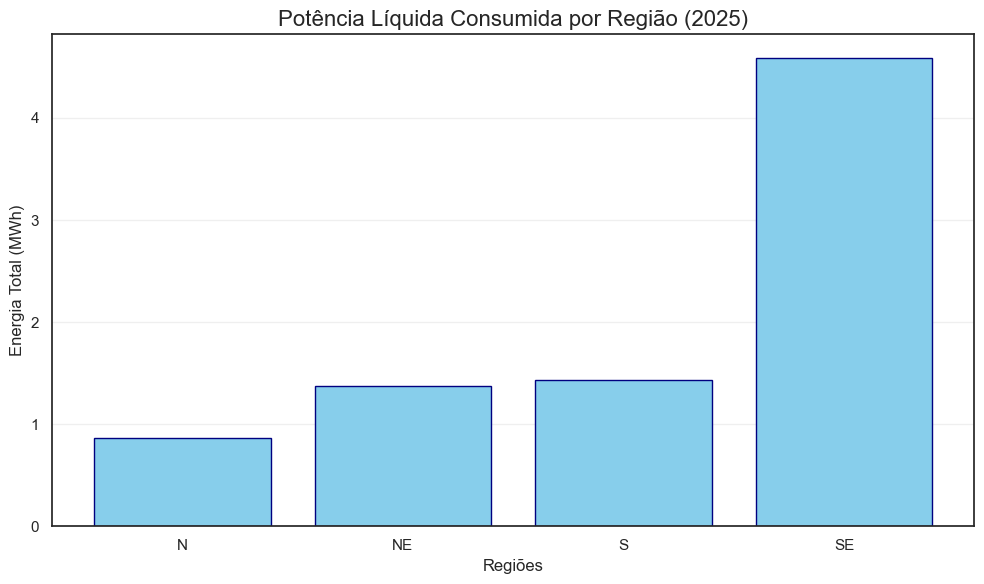

In [ ]:
soma = []
regioes = np.unique(data_array[:, 0])  # regiões únicas

for regiao in regioes:
    filtro = data_array[:, 0] == regiao
    valores = data_array[filtro][:, 3].astype(float)

    soma.append(np.sum(valores) / 1e9)  # convertendo para MWh

# gráfico fora do loop
plt.figure(figsize=(10, 6))
plt.bar(regioes, soma, color='skyblue', edgecolor='navy')

plt.title('Potência Líquida Consumida por Região (2025)', fontsize=16)
plt.xlabel('Regiões', fontsize=12)
plt.ylabel('Energia Total (MWh)', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
#plt.savefig('figuras/Potência Líquida Consumida por Região (2025).png')
plt.show()

<span style="color:blue">Note que há uma notável hierarquia de carga. O gráfico evidencia qual região detém o maior patamar de consumo. Nesse caso, o subsistema Sudeste.</span>

### 5.2. Evolução da Potência Líquida Regional (Visão Anual)
<span style="color:red">
O gráfico abaixo apresenta a carga consolidada ao longo dos meses do ano, segmentada pelos subsistemas do Sistema Interligado Nacional (SIN). Esta análise permite observar as variações de demanda de longo prazo e o peso relativo de cada região.
</span>

[ 1  2  3  4  5  6  7  8  9 10 11 12]


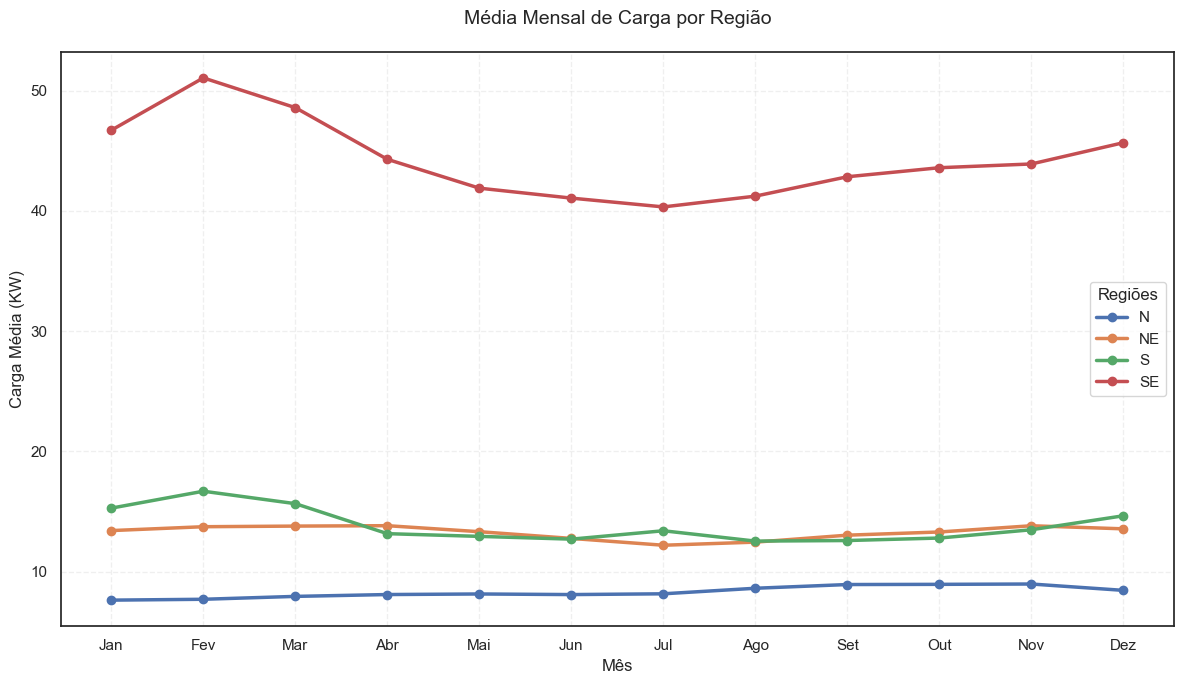

In [ ]:
regiões = []
meses = np.array(range(1,13))
print(meses)
df["Data"]= pd.to_datetime(df["Data"])
df["Mes"] = df["Data"].dt.month
df["Carga_KW"] = df["Carga"] / 1e3

meses = df.groupby(["Regioes","Mes"])["Carga_KW"].mean().reset_index()

# Plot das 4 curvas no mesmo gráfico
plt.figure(figsize=(12, 7))

regioes_unicas = df["Regioes"].unique()   # pega as 4 regiões automaticamente

for regiao in regioes_unicas:
    dados_regiao = meses[meses["Regioes"] == regiao]
    plt.plot(dados_regiao["Mes"],
             dados_regiao["Carga_KW"],
             marker='o',
             linewidth=2.5,
             label=regiao.strip())   # .strip() para remover espaços extras no nome

plt.title("Média Mensal de Carga por Região", fontsize=14, pad=20)
plt.xlabel("Mês", fontsize=12)
plt.ylabel("Carga Média (KW)", fontsize=12)
plt.xticks(range(1, 13),
           ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
            'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

plt.legend(title="Regiões", fontsize=11, title_fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
#plt.savefig('figuras/Média Mensal de Carga por Região.png')
plt.show()

<span style="color:blue">

* **Predomínio do Subsistema Sudeste/Centro-Oeste (SE/CO)**: Fica evidente que a região SE/CO representa a maior parcela da carga nacional, operando em patamares significativamente superiores aos demais subsistemas. Isso se deve à maior concentração de polos industriais e centros urbanos.
* **Sazonalidade Climática**: É possível observar flutuações que coincidem com os períodos sazonais brasileiros. Por exemplo, o aumento da carga em períodos de temperaturas elevadas (verão), devido ao uso intensivo de sistemas de refrigeração e climatização, o que exerce pressão direta sobre a oferta de energia.
* **Comportamento do Subsistema Sul (S)**: Observa-se que a região Sul mantém uma carga relevante, mas com variações que podem ser influenciadas por ciclos específicos da indústria local e do clima temperado da região.
* **Subsistemas Norte (N) e Nordeste (NE)**: Apresentam patamares de carga menores em comparação ao SE/CO, porém com curvas que demonstram crescimento e estabilidade. A relação entre a carga dessas regiões e o PLD é interessante, pois muitas vezes essas regiões exportam energia para o SE/CO quando possuem excedente hídrico ou eólico.
* **Implicações para o T2**: A clara distinção entre as escalas de potência das regiões reforça a necessidade de normalização dos dados na fase de Machine Learning, garantindo que a magnitude da carga do Sudeste não mascare o comportamento estatístico das outras regiões durante o treinamento do modelo.
</span>

### 5.3. Distribuição da Potência por Período do Ano
<span style="color:red">
O gráfico abaixo detalha o comportamento da demanda segmentada por diferentes períodos. Esta visualização permite uma análise mais precisa da oscilação sazonal da potência.</span>

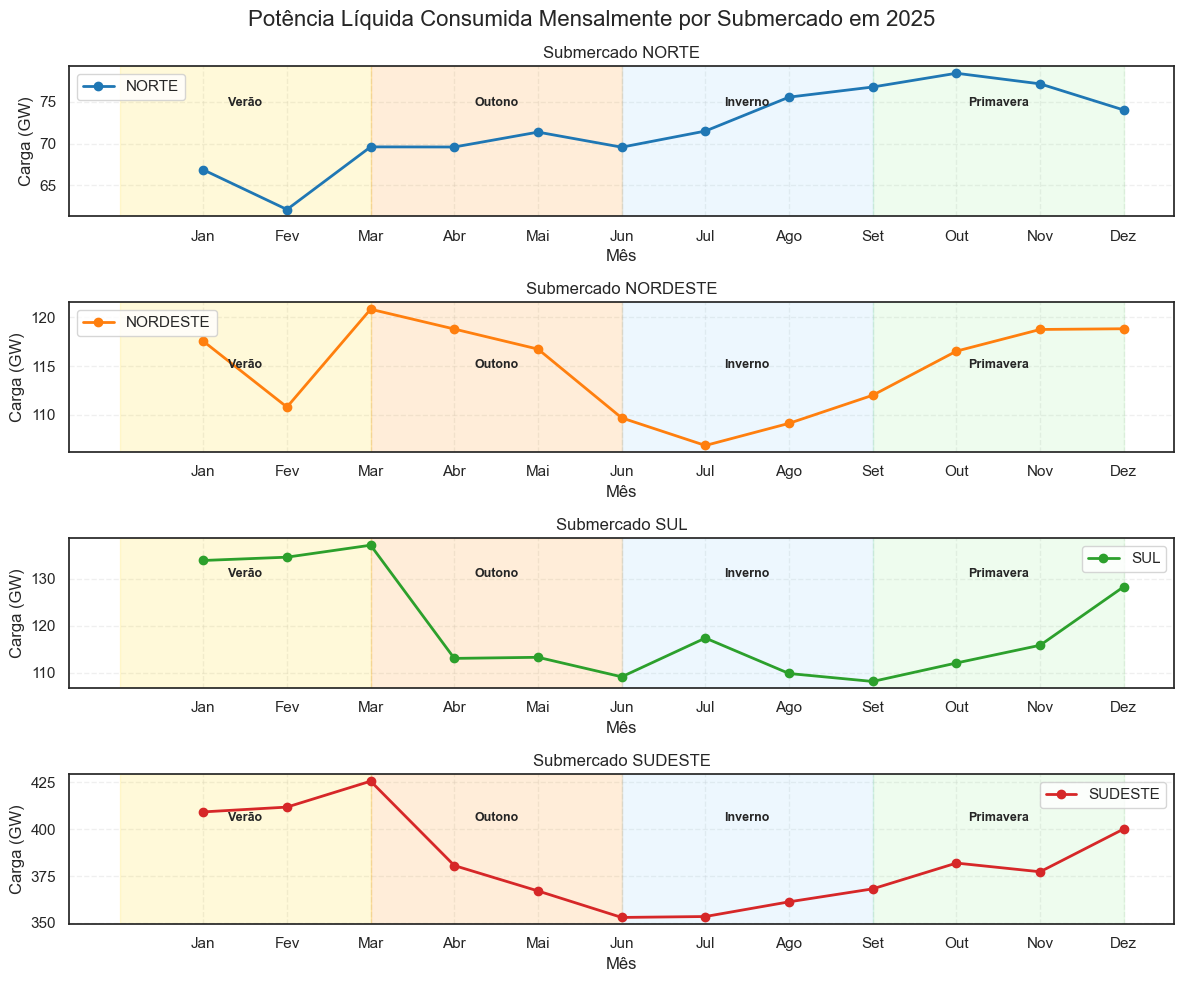

In [ ]:
import matplotlib.pyplot as plt

# =========================
# DADOS
# =========================

meses = df.groupby(["SUBMERCADO", "Mes"])["Carga_KW"].sum().reset_index()

# =========================
# MOSAICO
# =========================

mosaico = "AA;BB;CC;DD"
fig = plt.figure(figsize=(12,10))
axs = fig.subplot_mosaic(mosaico)

regioes_unicas = df["SUBMERCADO"].unique()
chaves = ["A", "B", "C", "D"]
mapa = dict(zip(regioes_unicas, chaves))

cores = dict(zip(regioes_unicas, plt.cm.tab10.colors))

# =========================
# ESTAÇÕES CORRETAS (Brasil)
# =========================

estacoes = [
    (0, 3, "Verão"),
    (3, 6, "Outono"),
    (6, 9, "Inverno"),
    (9, 12, "Primavera")
]

# cores só para estações (se quiser diferenciar)
cores_estacoes = {
    "Verão": "#FFD700",
    "Outono": "#FF8C00",
    "Inverno": "#87CEFA",
    "Primavera": "#90EE90"
}

# =========================
# LOOP
# =========================

for regiao in regioes_unicas:

    dados = meses[meses["SUBMERCADO"] == regiao].sort_values("Mes")
    dados["Carga_GW"] = dados["Carga_KW"] / 1e3
    ax = axs[mapa[regiao]]

    ymax = dados["Carga_GW"].max()

    # estações
    for inicio, fim, nome in estacoes:

        ax.axvspan(inicio, fim, color=cores_estacoes[nome], alpha=0.15)

        ax.text(
            (inicio + fim) / 2,
            ymax * 0.95,
            nome,
            ha="center",
            fontsize=9,
            weight="bold"
        )

    # linha principal
    ax.plot(
        dados["Mes"],
        dados["Carga_GW"],
        marker="o",
        linewidth=2,
        label=regiao,
        color=cores[regiao]
    )

    ax.set_title(f"Submercado {regiao}")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Carga (GW)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([
        'Jan','Fev','Mar','Abr','Mai','Jun',
        'Jul','Ago','Set','Out','Nov','Dez'
    ])

    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend()

# =========================
# FINAL
# =========================

fig.suptitle("Potência Líquida Consumida Mensalmente por Submercado em 2025", fontsize=16)
fig.tight_layout()
#plt.savefig('figuras/Potência Líquida Consumida Mensalmente por Submercado em 2025.png')
plt.show()

<span style="color:blue">O gráfico evidencia um comportamento sazonal bem definido do consumo ao longo de 2025: há maiores níveis de carga no verão e na primavera, enquanto ocorre uma redução durante o outono e principalmente no inverno. Em geral, observa-se queda a partir de março/abril, atingindo mínimos entre junho e agosto, seguida de recuperação gradual até o final do ano.</span>

### <span style="color:red"> 5.4. Consumo Horário </span>

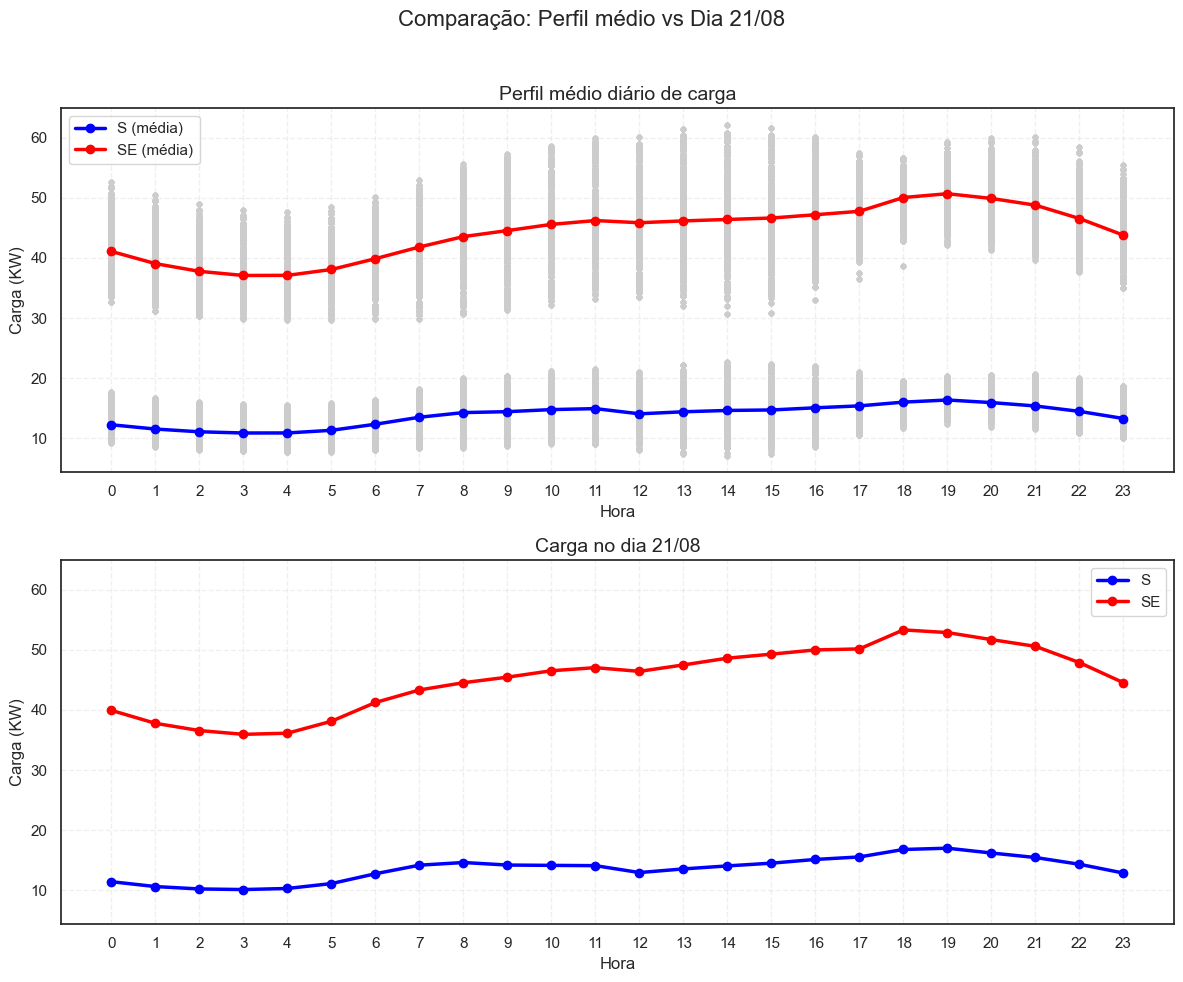

In [ ]:
# =========================
# PREPARAÇÃO DOS DADOS
# =========================

# Garantir cópia segura
df_filtrado = df[df["Regioes"].isin(["S", "SE"])].copy()

# Converter data corretamente
df_filtrado["Data"] = pd.to_datetime(df_filtrado["Data"], dayfirst=True)



# =========================
# CRIAÇÃO DOS GRÁFICOS
# =========================

mosaico = "AA;BB"
fig = plt.figure(figsize=(12,10))
axs = fig.subplot_mosaic(mosaico)

regioes = ["S", "SE"]
cores = {"S": "blue", "SE": "red"}

# =========================
# GRÁFICO 1 - MÉDIA ANUAL
# =========================

# =========================
# GRÁFICO 1 - MÉDIA + DISPERSÃO
# =========================

horas_media = (
    df_filtrado
    .groupby(["Regioes", "HORA"])["Carga_KW"]
    .mean()
    .reset_index()
)

for regiao in regioes:

    # dados reais (dispersão)
    dados_raw = df_filtrado[df_filtrado["Regioes"] == regiao]

    axs['A'].scatter(
        dados_raw["HORA"],
        dados_raw["Carga_KW"],
        alpha=0.4,
        s=10,
        color=(0.8, 0.8, 0.8)
    )

    # média (linha)
    dados_media = horas_media[horas_media["Regioes"] == regiao].sort_values("HORA")

    axs['A'].plot(
        dados_media["HORA"],
        dados_media["Carga_KW"],
        marker='o',
        linewidth=2.5,
        label=f"{regiao} (média)",
        color=cores[regiao]
    )
axs['A'].set_title("Perfil médio diário de carga", fontsize=14)
axs['A'].set_xlabel("Hora")
axs['A'].set_ylabel("Carga (KW)")
axs['A'].set_xticks(range(24))
axs['A'].grid(True, alpha=0.3, linestyle='--')
axs['A'].legend()

# =========================
# GRÁFICO 2 - DIA 21/08
# =========================
# Filtrar dia específico (21/08)
df_filtrado_FData = df_filtrado[
    df_filtrado["Data"].dt.date == pd.to_datetime("2025-08-21").date()

]
horas_dia = df_filtrado_FData.groupby(["Regioes", "HORA"])["Carga_KW"].mean().reset_index()

for regiao in regioes:
    dados = horas_dia[horas_dia["Regioes"] == regiao].sort_values("HORA")

    axs['B'].plot(
        dados["HORA"],
        dados["Carga_KW"],
        marker='o',
        linewidth=2.5,
        label=regiao,
        color=cores[regiao]
    )

axs['B'].set_title("Carga no dia 21/08", fontsize=14)
axs['B'].set_xlabel("Hora")
axs['B'].set_ylabel("Carga (KW)")
axs['B'].set_xticks(range(24))
axs['B'].grid(True, alpha=0.3, linestyle='--')
axs['B'].legend()

# =========================
# AJUSTE FINAL
# =========================

# Igualar escala dos gráficos (comparação justa)
ymin = min(axs['A'].get_ylim()[0], axs['B'].get_ylim()[0])
ymax = max(axs['A'].get_ylim()[1], axs['B'].get_ylim()[1])

axs['A'].set_ylim(ymin, ymax)
axs['B'].set_ylim(ymin, ymax)

fig.suptitle("Comparação: Perfil médio vs Dia 21/08", fontsize=16)

fig.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig('figuras/Comparação - Perfil médio vs Dia 21-08.png')
plt.show()

<span style="color:blue">O gráfico evidencia um perfil diário típico de carga, com mínimos na madrugada, seguido de elevação contínua pela manhã e estabilização durante a tarde, culminando em um pico no início da noite (aprox. 18h–20h) e queda gradual após esse horário. Evidenciando o conhecido Horário de ponta. </span>


### 5.5 <span style="color:green">Carga regional diária</span>

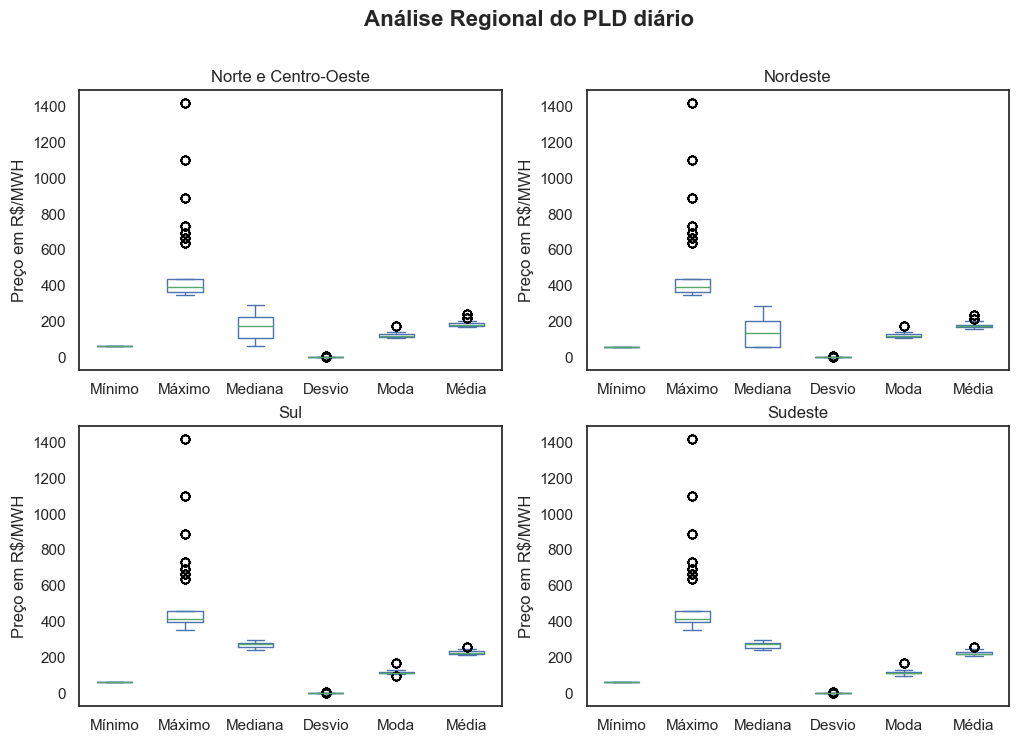

Text(0.5, 0.98, 'Análise Regional da carga diária')

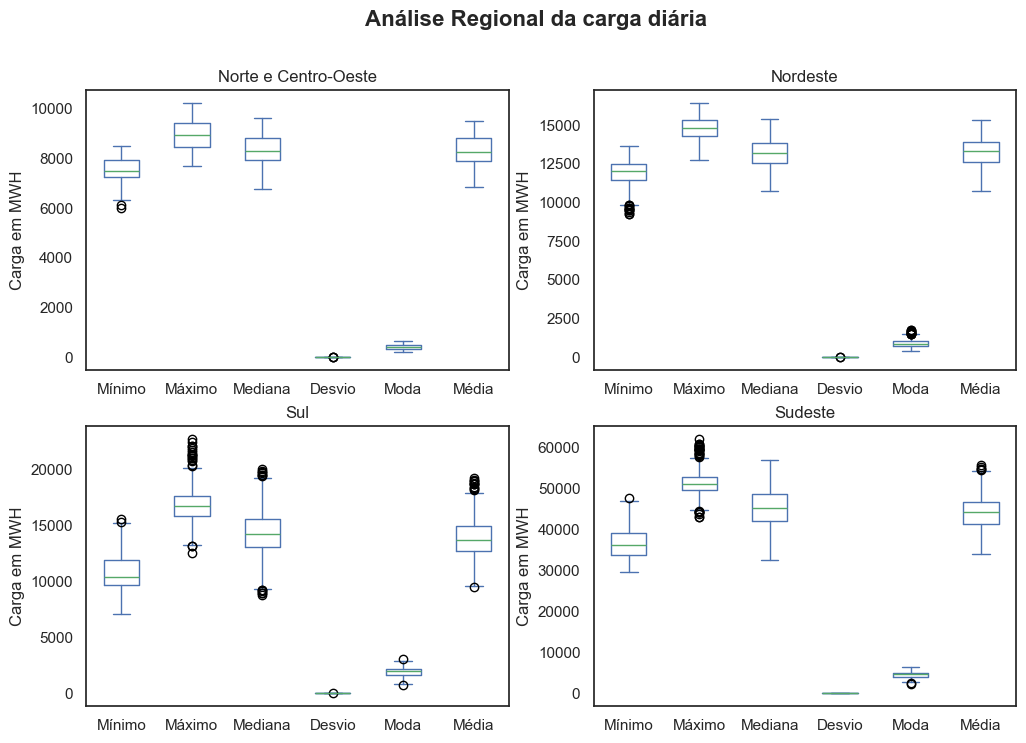

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('CURVA_CARGA_2025.csv', sep=';')
df = df.rename(columns={"id_subsistema":"Regioes S","nom_subsistema":"Regioes ","Data":"din_instante","val_cargaenergiahomwmed":"Carga"})
dfo = pd.read_csv('CURVA_CARGA_2025.csv', sep=';')
dfo = dfo.rename(columns={"id_subsistema":"Regioes","nom_subsistema":"SUBMERCADO","din_instante":"Data","val_cargaenergiahomwmed":"Carga"})
dfo['Data'] = pd.to_datetime(dfo['Data'])

dfo["Mes"] = dfo["Data"].dt.month
dfo["DIA"] = dfo["Data"].dt.day
dfo["HORA"] = dfo["Data"].dt.hour

dfo2 = pd.read_csv('pld_horario_2025.csv', sep=';')
df = pd.merge(dfo, dfo2, on=['SUBMERCADO', 'DIA', 'HORA'], how='inner')
df['Custos_Milhoes'] = (df['Carga'] * df['PLD_HORA']) / 1e6


estatistica_dia_pld_group = df[["DIA", "Mes", "Regioes" , "PLD_HORA", "Carga"]].groupby(["Mes", "DIA", "Regioes"])
estatistica_dia_pld= estatistica_dia_pld_group.agg({
  "PLD_HORA": ["min", "max", "median", "skew", "std", "mean"
               ]
})["PLD_HORA"]

estatistica_dia_carga_group = df[["DIA", "Mes", "Regioes", "PLD_HORA", "Carga"]].groupby(["Mes", "DIA", "Regioes"])
estatistica_dia_carga= estatistica_dia_pld_group.agg({
  "Carga": ["min", "max", "median", "skew", "std", "mean"
            ]
})["Carga"]
estatistica_dia_carga = estatistica_dia_carga.rename(columns={
  "max":"Máximo","min":"Mínimo","std":"Moda","mean":"Média","median":"Mediana", "skew":"Desvio"})

estatistica_dia_pld = estatistica_dia_pld.rename(columns={
  "max":"Máximo","min":"Mínimo","std":"Moda","mean":"Média","median":"Mediana", "skew":"Desvio",})

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes_flat = axes.flatten()

regioes = ["Norte e Centro-Oeste", "Nordeste", "Sul", "Sudeste"]

for i, reg in enumerate(["N", "NE", "S", "SE"]):
  ax = estatistica_dia_pld.loc[:, :, reg].plot.box(figsize=(12, 8), ax=axes_flat[i])
  ax.set_ylabel("Preço em R$/MWH")
  ax.set_title(regioes[i])
fig.suptitle("Análise Regional do PLD diário", fontsize=16, fontweight='bold')
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes_flat = axes.flatten()

for i, reg in enumerate(["N", "NE", "S", "SE"]):
  ax = estatistica_dia_carga.loc[:, :, reg].plot.box(figsize=(12, 8), ax=axes_flat[i])
  ax.set_ylabel("Carga em MWH")
  ax.set_title(regioes[i])
fig.suptitle("Análise Regional da carga diária", fontsize=16, fontweight='bold')
#plt.savefig('figuras/Análise Regional da carga diária.png')


<span style="color:blue">A análise da Carga Regional Diária evidencia a heterogeneidade do consumo no Sistema Elétrico Brasileiro (SEB). Como já comentado o submercado Sudeste consolida-se como o polo de maior demanda e variabilidade, apresentando a maior amplitude térmica-operacional. As regiões Sul e Sudeste demonstram maior sensibilidade a eventos extremos, conforme indicado pela densidade de outliers nos valores máximos. Em contrapartida, as regiões Norte e Nordeste exibem perfis de carga mais lineares e previsíveis. De forma geral, a predominância da Média sobre a Mediana em todos os subsistemas ressalta um regime de operação pressionado por picos de demanda, fator determinante para o planejamento do despacho e da segurança energética.</span>

### 5.6 Dispersão de carga
<span style="color:green">
A análise estatística através de curvas de dispersão é fundamental para entender a flexibilidade exigida do parque gerador. Enquanto os gráficos de boxplot anteriores mostravam estatísticas descritivas, estas curvas de densidade revelam a "assinatura de consumo" de cada região. Curvas mais altas e estreitas indicam uma carga estável e previsível; curvas baixas e alongadas indicam grande variabilidade e desafios maiores para o despacho em tempo real.
</span>


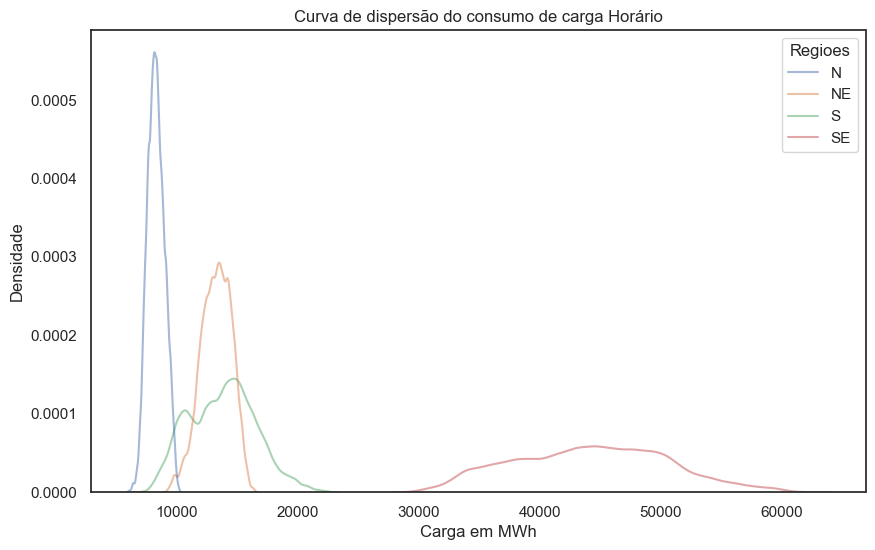

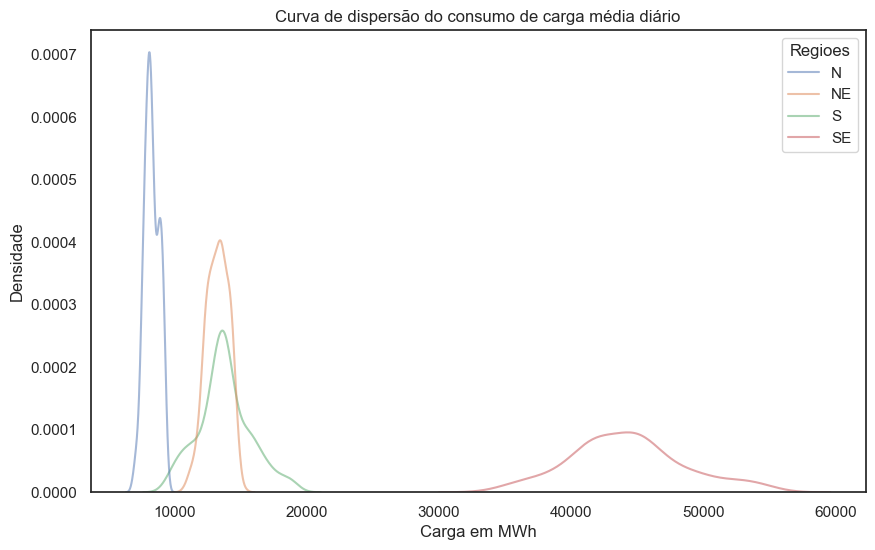

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Plot for Carga
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="Carga",
            hue="Regioes", fill=False,       # Preenche a área sob a curva
            alpha=0.5, common_norm=False)

plt.title("Curva de dispersão do consumo de carga Horário")
plt.xlabel("Carga em MWh")
plt.ylabel("Densidade")
#plt.savefig('figuras/Curva de dispersão do consumo de carga Horário.png')
plt.show()
# 2. Plot for Carga
plt.figure(figsize=(10, 6))
sns.kdeplot(data=estatistica_dia_carga, x="Média",
            hue="Regioes", fill=False,       # Preenche a área sob a curva
            alpha=0.5, common_norm=False)

plt.title("Curva de dispersão do consumo de carga média diário")
plt.xlabel("Carga em MWh")
plt.ylabel("Densidade")
#plt.savefig('figuras/Curva de dispersão do consumo de carga média diário.png')
plt.show()

<span style="color:blue">A comparação entre as curvas de dispersão horária e diária evidencia o efeito de suavização estatística sobre a demanda. A análise revela que o submercado Sudeste enfrenta os maiores desafios de flexibilidade, dada a sua distribuição quase plana no regime horário, exigindo uma resposta rápida e robusta do sistema de geração. Em contrapartida, as regiões Norte e Nordeste exibem perfis de consumo mais resilientes e centrados em suas médias, o que facilita o planejamento de longo prazo, mas não as exime da necessidade de gestão de ponta, conforme observado na dilatação das bases das curvas horárias.</span>

### <span style="color:blue">5.7. Análise do PLD Médio Mensal e Correlação de Mercado</span>

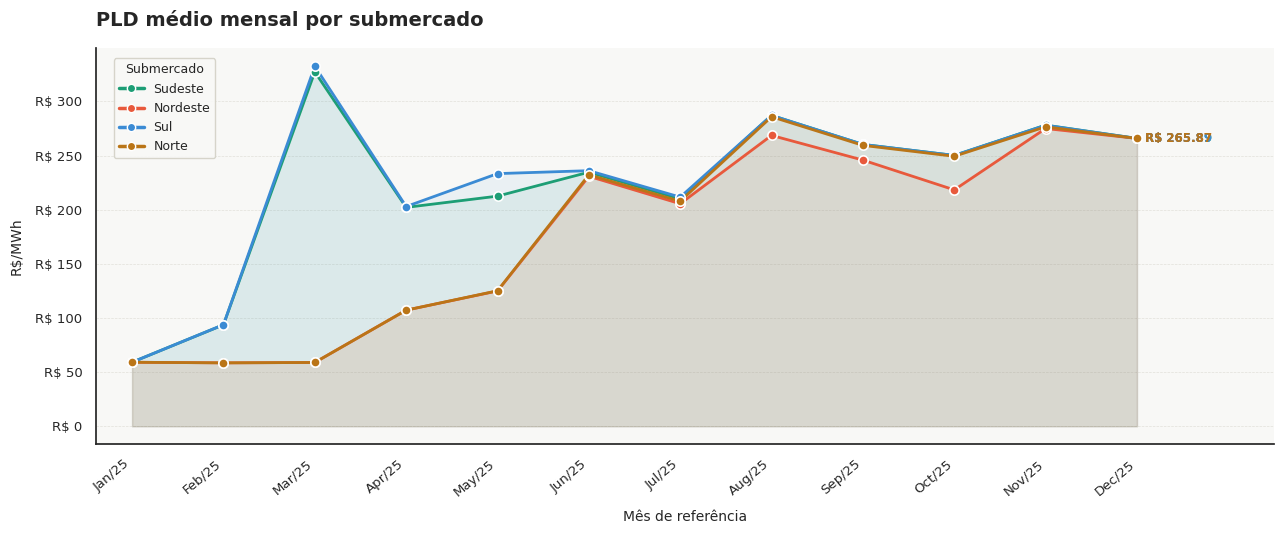

In [ ]:
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

df2 = pd.read_csv('pld_horario_2025.csv', sep=';')
#print(df2.head())
df2["MES_REFERENCIA"] = df2["MES_REFERENCIA"].astype(str)
df2["PLD_HORA"]       = pd.to_numeric(df2["PLD_HORA"], errors="coerce")

# ── 2. Média mensal por submercado ────────────────────────────────────────────
media_mensal = (
    df2
    .groupby(["MES_REFERENCIA", "SUBMERCADO"])["PLD_HORA"]
    .mean()
    .reset_index()
    .rename(columns={"PLD_HORA": "PLD_MEDIO"})
)

# ── 3. Converter YYYYMM → datetime e criar rótulo "Mmm/AA" ───────────────────
media_mensal["DATA"] = pd.to_datetime(
    media_mensal["MES_REFERENCIA"], format="%Y%m"
)
media_mensal["ROTULO"] = media_mensal["DATA"].dt.strftime("%b/%y").str.capitalize()

# Ordenar cronologicamente
media_mensal = media_mensal.sort_values("DATA")

# Meses únicos ordenados (para o eixo X)
meses_ord  = media_mensal.drop_duplicates("DATA").sort_values("DATA")
rotulos    = meses_ord["ROTULO"].tolist()
x_pos      = np.arange(len(rotulos))          # 0, 1, 2 …

# ── 4. Estilo ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.facecolor":    "#F8F8F6",
    "figure.facecolor":  "#FFFFFF",
    "grid.color":        "#D3D1C7",
    "grid.linewidth":    0.5,
})

SUBMERCADOS = ["SUDESTE", "NORDESTE", "SUL", "NORTE"]
CORES = {
    "SUDESTE":  "#1D9E75",
    "NORDESTE": "#E8593C",
    "SUL":      "#3B8BD4",
    "NORTE":    "#BA7517",
}

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5.5))

for sub in SUBMERCADOS:
    dados = (
        media_mensal[media_mensal["SUBMERCADO"] == sub]
        .set_index("ROTULO")
        .reindex(rotulos)           # garante a ordem correta
    )
    cor = CORES[sub]

    # Linha principal
    ax.plot(
        x_pos, dados["PLD_MEDIO"],
        color=cor, linewidth=2, zorder=3,
    )
    # Área preenchida sob a linha
    ax.fill_between(
        x_pos, dados["PLD_MEDIO"],
        alpha=0.07, color=cor, zorder=2,
    )
    # Marcadores
    ax.scatter(
        x_pos, dados["PLD_MEDIO"],
        color=cor, s=45, zorder=4,
        edgecolors="white", linewidths=1.2,
    )
    # Rótulo de valor no último ponto
    ultimo_val = dados["PLD_MEDIO"].dropna()
    if not ultimo_val.empty:
        ix = ultimo_val.index.get_loc(ultimo_val.index[-1])
        ax.annotate(
            f"R$ {ultimo_val.iloc[-1]:.2f}",
            xy=(len(rotulos) - 1, ultimo_val.iloc[-1]),
            xytext=(6, 0), textcoords="offset points",
            color=cor, fontsize=8.5, va="center", fontweight="bold",
        )

# ── 6. Eixos e grade ──────────────────────────────────────────────────────────
ax.set_xticks(x_pos)
ax.set_xticklabels(rotulos, rotation=40, ha="right", fontsize=9.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
ax.tick_params(axis="y", labelsize=9.5)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.set_xlim(-0.4, len(rotulos) - 1 + 1.5)   # espaço p/ rótulos do último ponto

# ── 7. Títulos ────────────────────────────────────────────────────────────────
ax.set_title(
    "PLD médio mensal por submercado",
    fontsize=14, fontweight="bold", pad=16, loc="left",
)
ax.set_xlabel("Mês de referência", fontsize=10, labelpad=8)
ax.set_ylabel("R$/MWh", fontsize=10, labelpad=8)

# ── 8. Legenda customizada ────────────────────────────────────────────────────
handles = [
    Line2D([0], [0], color=CORES[s], linewidth=2.5,
           marker="o", markersize=6,
           markerfacecolor=CORES[s], markeredgecolor="white", markeredgewidth=1,
           label=s.capitalize())
    for s in SUBMERCADOS
]
ax.legend(
    handles=handles,
    title="Submercado", title_fontsize=9,
    fontsize=9, framealpha=0.92,
    loc="upper left", bbox_to_anchor=(0.01, 0.99),
    frameon=True, edgecolor="#D3D1C7",
)

plt.tight_layout()
#plt.savefig('figuras/PLD médio mensal por submercado.png')
plt.show()


<span style="color:blue">O gráfico de médias mensais do PLD revela a dinâmica de preços entre os diferentes submercados do Sistema Interligado Nacional (SIN). A partir da visualização, observam-se os seguintes pontos:

<span style="color:blue">* **Pico em Março (Sul e Sudeste/Centro-Oeste)**: Há um salto acentuado nos custos dessas regiões no mês de março. Esse comportamento é um reflexo direto da aversão ao risco do mercado. Março marca o fim do "período úmido"; se os níveis de reservatórios não atingem patamares confortáveis até esse mês, o mercado antecipa o cenário de escassez (secas) dos meses seguintes, elevando o Custo Marginal de Operação (CMO) e, consequentemente, o PLD. Esse comportamento é tecnicamente chamado de Expectativa de Afluência. No Brasil, o PLD é calculado por modelos matemáticos (como o NEWAVE e DECOMP) que olham para o futuro. Se em março a previsão de chuva para o resto do ano é ruim, os modelos aumentam o preço imediatamente para desestimular o consumo e preservar água, o que justifica exatamente o que podemos ver no gráfico.

<span style="color:blue">* **Transmissão de Preços (Diferencial de Base)**: A subida subsequente dos preços nas demais regiões (Norte e Nordeste) demonstra o comportamento típico de anos de seca. Quando o subsistema principal (Sudeste) entra em estresse, o sistema passa a importar energia de outras regiões. Assim que os limites de intercâmbio entre as regiões são atingidos, o PLD tende a subir em todo o território para refletir a necessidade de acionamento de térmicas mais caras em todo o SIN.</span>

### 5.8. <span style="color:green">Análise regional do PLD Diário
O seguinte gráfico foi gerado a fim de observar o comportamento de todas as variáveis estatísticas do PLD por região.</span>

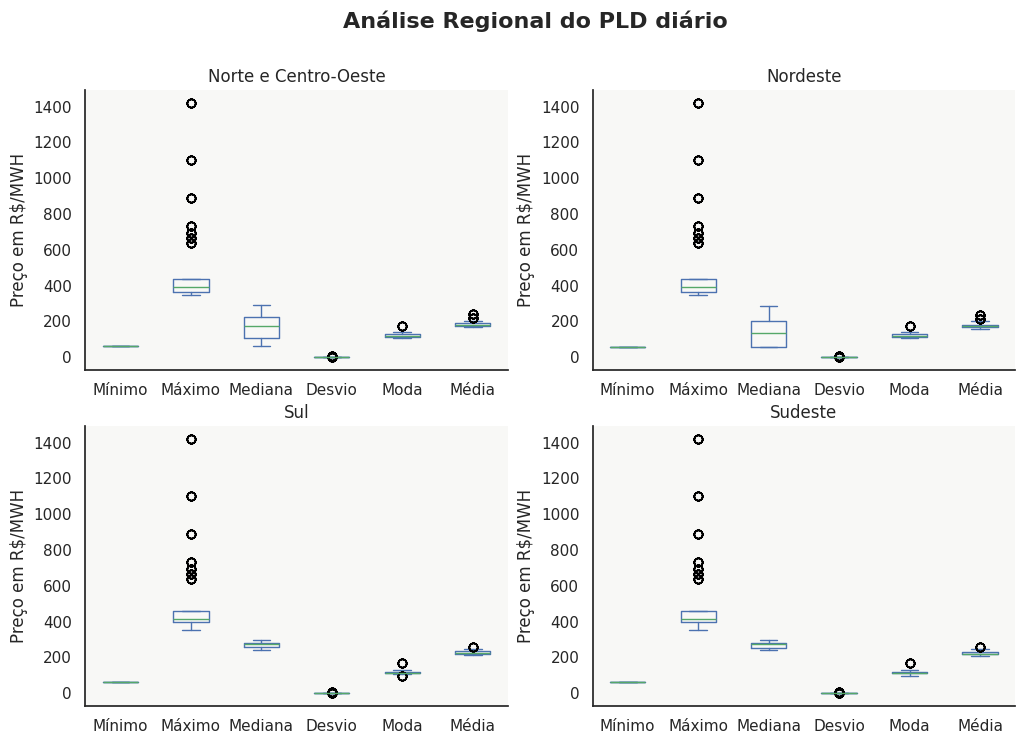

Text(0.5, 0.98, 'Análise Regional da carga diária')

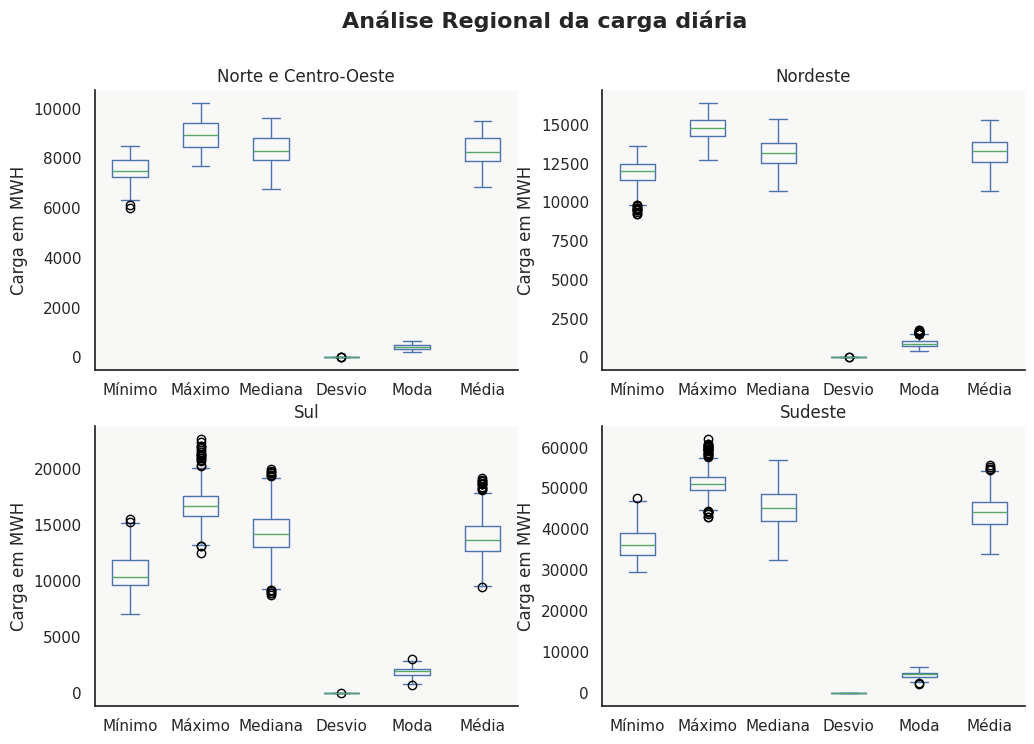

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('CURVA_CARGA_2025.csv', sep=';')
df = df.rename(columns={"id_subsistema":"Regioes S","nom_subsistema":"Regioes ","Data":"din_instante","val_cargaenergiahomwmed":"Carga"})
dfo = pd.read_csv('CURVA_CARGA_2025.csv', sep=';')
dfo = dfo.rename(columns={"id_subsistema":"Regioes","nom_subsistema":"SUBMERCADO","din_instante":"Data","val_cargaenergiahomwmed":"Carga"})
dfo['Data'] = pd.to_datetime(dfo['Data'])

dfo["Mes"] = dfo["Data"].dt.month
dfo["DIA"] = dfo["Data"].dt.day
dfo["HORA"] = dfo["Data"].dt.hour

dfo2 = pd.read_csv('pld_horario_2025.csv', sep=';')
df = pd.merge(dfo, dfo2, on=['SUBMERCADO', 'DIA', 'HORA'], how='inner')
df['Custos_Milhoes'] = (df['Carga'] * df['PLD_HORA']) / 1e6


estatistica_dia_pld_group = df[["DIA", "Mes", "Regioes" , "PLD_HORA", "Carga"]].groupby(["Mes", "DIA", "Regioes"])
estatistica_dia_pld= estatistica_dia_pld_group.agg({
  "PLD_HORA": ["min", "max", "median", "skew", "std", "mean"
               ]
})["PLD_HORA"]

estatistica_dia_carga_group = df[["DIA", "Mes", "Regioes", "PLD_HORA", "Carga"]].groupby(["Mes", "DIA", "Regioes"])
estatistica_dia_carga= estatistica_dia_pld_group.agg({
  "Carga": ["min", "max", "median", "skew", "std", "mean"
            ]
})["Carga"]
estatistica_dia_carga = estatistica_dia_carga.rename(columns={
  "max":"Máximo","min":"Mínimo","std":"Moda","mean":"Média","median":"Mediana", "skew":"Desvio"})

estatistica_dia_pld = estatistica_dia_pld.rename(columns={
  "max":"Máximo","min":"Mínimo","std":"Moda","mean":"Média","median":"Mediana", "skew":"Desvio",})

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes_flat = axes.flatten()

regioes = ["Norte e Centro-Oeste", "Nordeste", "Sul", "Sudeste"]

for i, reg in enumerate(["N", "NE", "S", "SE"]):
  ax = estatistica_dia_pld.loc[:, :, reg].plot.box(figsize=(12, 8), ax=axes_flat[i])
  ax.set_ylabel("Preço em R$/MWH")
  ax.set_title(regioes[i])
fig.suptitle("Análise Regional do PLD diário", fontsize=16, fontweight='bold')
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes_flat = axes.flatten()

for i, reg in enumerate(["N", "NE", "S", "SE"]):
  ax = estatistica_dia_carga.loc[:, :, reg].plot.box(figsize=(12, 8), ax=axes_flat[i])
  ax.set_ylabel("Carga em MWH")
  ax.set_title(regioes[i])
fig.suptitle("Análise Regional da carga diária", fontsize=16, fontweight='bold')
#plt.savefig('figuras/Análise Regional da carga diária.png')


<span style="color:blue">A partir dos dados estatísticos apresentados, destacam-se três padrões fundamentais:

<span style="color:blue">* **Convergência do Piso Operacional**: Os valores mínimos apresentam uma constância quase absoluta entre as regiões, refletindo o piso regulatório e a margem mínima de custo operacional do sistema quando a oferta de energia barata (hidráulica e renovável) é abundante.

<span style="color:blue">* **Volatilidade em Picos de Carga**: Os valores máximos revelam uma alta dispersão com presença acentuada de outliers que ultrapassam R$ 1.400/MWh. Esse comportamento é simétrico em todos os submercados, evidenciando que picos de demanda ou restrições sistêmicas severas elevam o custo marginal de expansão de forma global, independentemente da localização geográfica.

<span style="color:blue">* **Estabilidade das Médias e Mediana**: Apesar da volatilidade nos extremos, a Moda e a Mediana situam-se em patamares estáveis (entre R$ 100 e R$ 300/MWh). Nota-se que os submercados Sul e Sudeste apresentam uma concentração de preços ligeiramente superior às regiões Norte e Nordeste, as quais se beneficiam de períodos de maior excedente energético sazonal.</span>

### 5.9. <span style="color:green">Análise regional do PLD Horário</span>

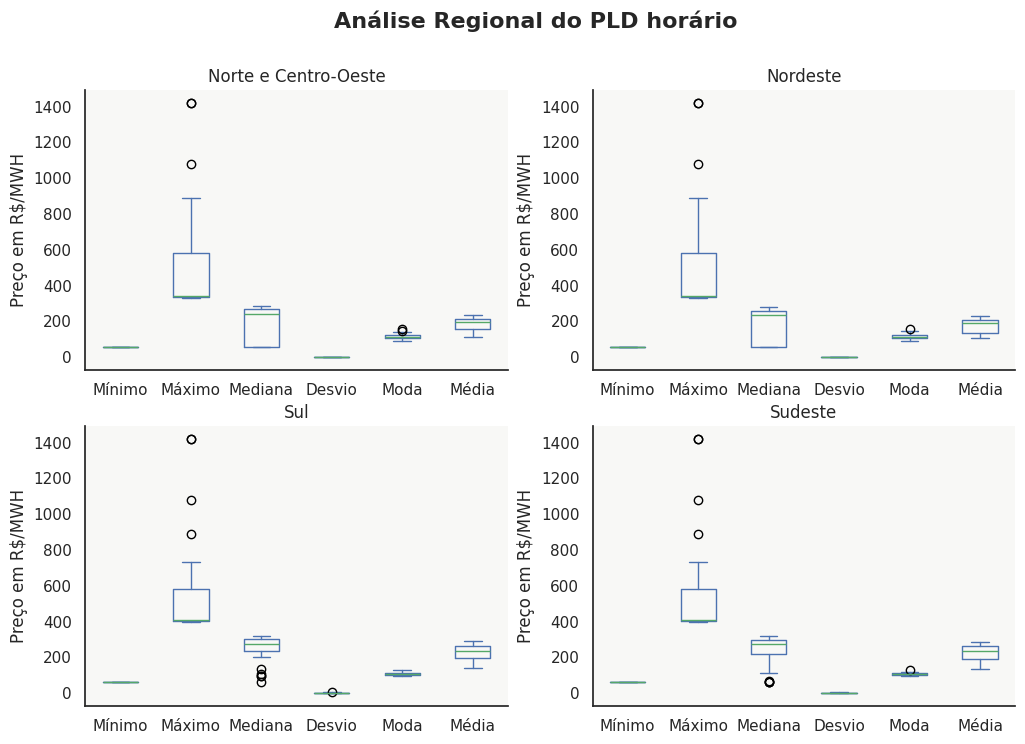

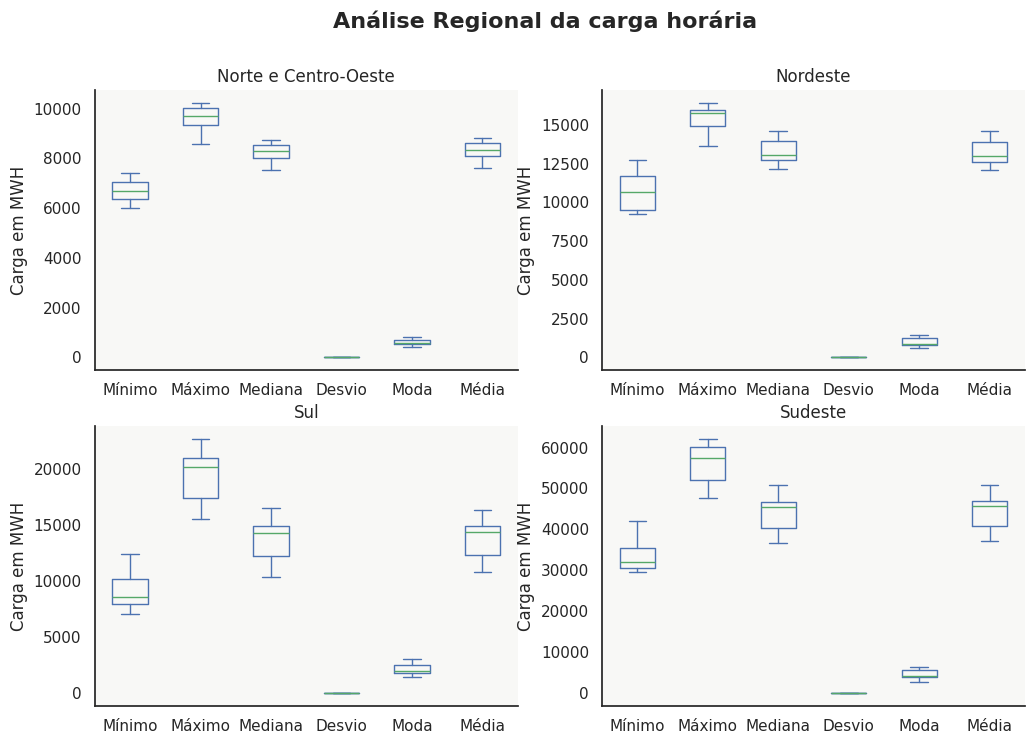

In [ ]:
estatistica_hora_pld_group = df[["HORA", "Regioes" , "PLD_HORA", "Carga"]].groupby(["HORA", "Regioes"])
estatistica_hora_pld= estatistica_hora_pld_group.agg({
  "PLD_HORA": ["min", "max", "median", "skew", "std", "mean"
               ]
})["PLD_HORA"]

estatistica_hora_carga_group = df[["HORA", "Regioes", "PLD_HORA", "Carga"]].groupby(["HORA", "Regioes"])
estatistica_hora_carga= estatistica_hora_pld_group.agg({
  "Carga": ["min", "max", "median", "skew", "std", "mean"
            ]
})["Carga"]
estatistica_hora_carga = estatistica_hora_carga.rename(columns={
  "max":"Máximo","min":"Mínimo","std":"Moda","mean":"Média","median":"Mediana", "skew":"Desvio"})

estatistica_hora_pld = estatistica_hora_pld.rename(columns={
  "max":"Máximo","min":"Mínimo","std":"Moda","mean":"Média","median":"Mediana", "skew":"Desvio"})

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes_flat = axes.flatten()

regioes = ["Norte e Centro-Oeste", "Nordeste", "Sul", "Sudeste"]

for i, reg in enumerate(["N", "NE", "S", "SE"]):
  ax = estatistica_hora_pld.xs(reg, level="Regioes")
  ax = ax.plot.box(figsize=(12, 8), ax=axes_flat[i])
  ax.set_ylabel("Preço em R$/MWH")
  ax.set_title(regioes[i])
fig.suptitle("Análise Regional do PLD horário", fontsize=16, fontweight='bold')
#plt.savefig('figuras/Análise Regional do PLD horário.png')
plt.show()
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes_flat = axes.flatten()

for i, reg in enumerate(["N", "NE", "S", "SE"]):
  ax = estatistica_hora_carga.xs(reg, level="Regioes")
  ax = ax.plot.box(figsize=(12, 8), ax=axes_flat[i])
  ax.set_ylabel("Carga em MWH")
  ax.set_title(regioes[i])
fig.suptitle("Análise Regional da carga horária", fontsize=16, fontweight='bold')
#plt.savefig('figuras/Análise Regional da carga horária.png')
plt.show()

<span style="color:blue">A análise do PLD Horário evidencia a volatilidade intrínseca ao modelo de formação de preços por submercado. Diferente da média diária, a escala horária revela uma maior dispersão nos valores máximos, reflexo direto das rampas de carga e da intermitência das fontes renováveis. Observa-se que os submercados Sul e Sudeste operam com médias horárias superiores, enquanto Norte e Nordeste apresentam uma mediana mais flexível, aproximando-se do piso operacional com maior frequência. A convergência dos valores mínimos em todas as regiões reafirma a integridade e o acoplamento sistêmico do SIN, mesmo sob condições de estresse horário.</span>

### <span style="color:green">5.10 Análise de Dispersão do PLD</span>

<span style="color:blue">
Diferente de outras variáveis de mercado, o PLD no Brasil não segue uma distribuição normal. Ele é caracterizado por longos períodos de estabilidade no piso (custo mínimo), interrompidos por picos abruptos de volatilidade. A análise de dispersão (KDE) é a ferramenta ideal para identificar esses "degraus" de preço, permitindo visualizar em quais faixas o mercado permanece a maior parte do tempo e qual o risco real de atingir o teto regulatório.

A análise de dispersão do PLD demonstra que o preço de curto prazo no SEB opera sob um regime de bimodalidade. No regime horário, a frequência de preços próximos ao piso é dominante, evidenciando o papel das fontes renováveis. Contudo, o descolamento regional observado no regime diário entre o bloco Norte/Nordeste e Sul/Sudeste ressalta a existência de limites de intercâmbio entre os submercados. Em suma, o PLD apresenta uma estabilidade estatística enganosa: enquanto a maior parte das horas opera em patamares baixos, a presença de outliers frequentes e a dispersão dos valores máximos exigem estratégias robustas de proteção contra a volatilidade extrema do sistema.</span>


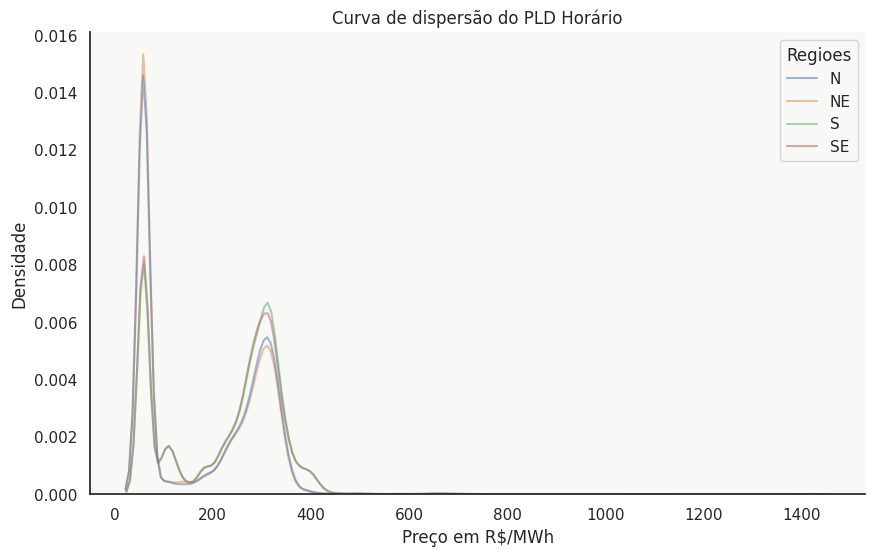

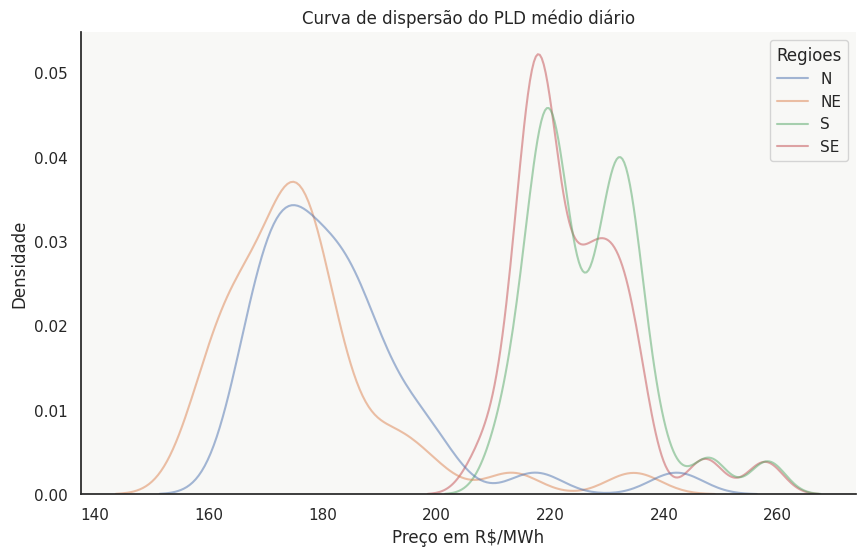

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Plot for PLD_HORA
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="PLD_HORA",
            hue="Regioes", fill=False,       # Preenche a área sob a curva
            alpha=0.5, common_norm=False)

plt.title("Curva de dispersão do PLD Horário")
plt.xlabel("Preço em R$/MWh")
plt.ylabel("Densidade")
# Seaborn handles the legend automatically based on 'hue'
#plt.savefig('figuras/Curva de dispersão do PLD Horário.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.kdeplot(data=estatistica_dia_pld, x="Média",
            hue="Regioes", fill=False,       # Preenche a área sob a curva
            alpha=0.5, common_norm=False)

plt.title("Curva de dispersão do PLD médio diário")
plt.xlabel("Preço em R$/MWh")
plt.ylabel("Densidade")
# Seaborn handles the legend automatically based on 'hue'
#plt.savefig('figuras/Curva de dispersão do PLD médio diário.png')
plt.show()

### <span style="color:red">5.11. Heatmap de custo por submercado por Hora
Uma primeira observação interessante do cruzamento dos datasets foi a derivação do custo horário por MWh por subsistema, pois isso permite relacionar diretamente demanda, sazonalidade diária e impacto econômico em cada região do SIN.</span>


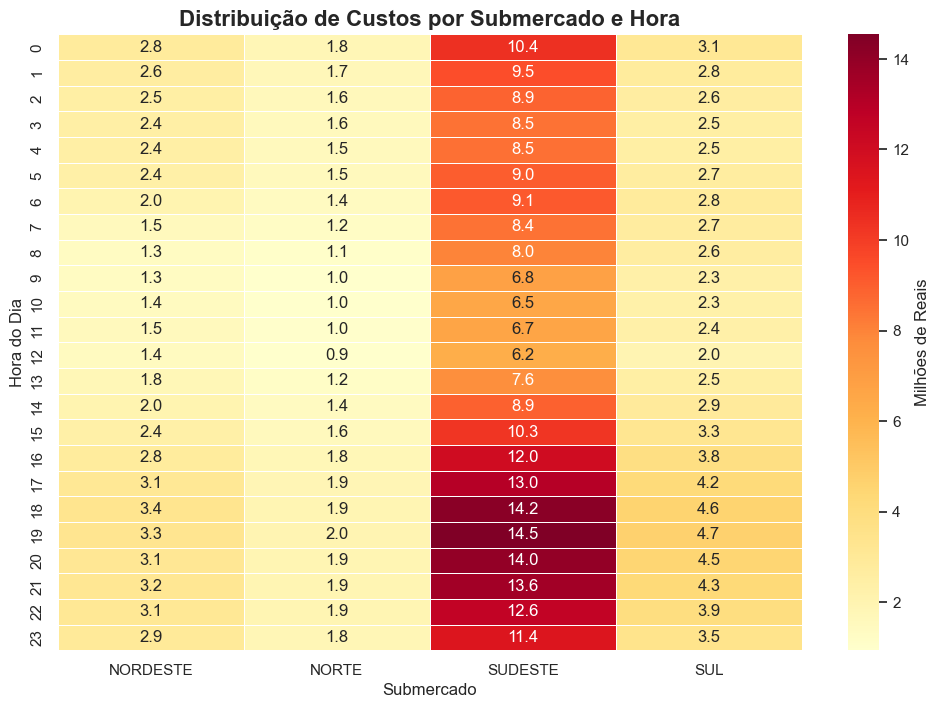

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Primeiro, criamos o pivot (ajuste os nomes das colunas se necessário)
# Se der erro aqui, verifique se o seu DataFrame se chama 'df' ou 'dfo'
pivot = df.pivot_table(
    values='Custos_Milhoes',
    index='HORA',
    columns='SUBMERCADO'
).fillna(0)

# 2. Agora o código do gráfico que usa o 'pivot' já definido acima
plt.figure(figsize=(12, 8))
sns.set_theme(style="white")

# Usando o pivot que acabamos de criar
ax = sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=.5,
    cbar_kws={'label': 'Milhões de Reais'}
)

plt.title("Distribuição de Custos por Submercado e Hora", fontsize=16, fontweight='bold')
plt.xlabel("Submercado")
plt.ylabel("Hora do Dia")

plt.show()

<span style="color:blue">O mapa de calor evidencia claramente um padrão intradiário de custos, com valores mais baixos durante a madrugada e manhã, e um aumento expressivo no final da tarde e início da noite (aprox. 17h–21h), coincidindo com o período típico de maior consumo. Esse comportamento reforça a relação entre pico de carga e encarecimento marginal da energia.
Além disso, observa-se que o Sudeste apresenta custos sistematicamente mais elevados, indicando maior peso econômico do submercado no custo total e possivelmente maior sensibilidade às condições de despacho e restrições operativas. Já Norte e Nordeste mantêm valores menores e mais estáveis, sugerindo menor pressão de custo relativo ao longo do dia.
</span>

<span style="color:blue">
Com base nesse gráfico, algumas análises possíveis incluem:
* Identificação das horas críticas de custo, úteis para estratégias de consumo e planejamento operacional.
* Comparação entre subsistemas para avaliar quais regiões concentram maior impacto financeiro no despacho.
* Avaliação de volatilidade horária, observando quais submercados apresentam maior variação ao longo do dia.
</span>


## 6. Correlação e Dependência	
<span style="color:blue">
A análise do PLD Horário evidencia a volatilidade intrínseca ao modelo de formação de preços por submercado. Diferente da média diária, a escala horária revela uma maior dispersão nos valores máximos, reflexo direto das rampas de carga e da intermitência das fontes renováveis. Observa-se que os submercados Sul e Sudeste operam com médias horárias superiores, enquanto Norte e Nordeste apresentam uma mediana mais flexível, aproximando-se do piso operacional com maior frequência. A convergência dos valores mínimos em todas as regiões reafirma a integridade e o acoplamento sistêmico do SIN, mesmo sob condições de estresse horário.
</span>

### 6.1. A Dinâmica Carga-Preço no Sudeste
<span style="color:blue">
A tentativa de mapear o PLD em função da Carga por meio de um gráfico de dispersão justifica-se pela busca da elasticidade-preço do sistema. Em teoria, o Preço de Liquidação das Diferenças deveria seguir a curva de custo marginal de operação (CMO): quanto maior a carga, mais usinas caras (térmicas) precisam ser acionadas, elevando o preço. O uso deste gráfico é essencial para identificar se essa relação é linear, se existem "zonas de saturação" ou se outros fatores (como a geração renovável intermitente) estão quebrando essa correlação.
</span>

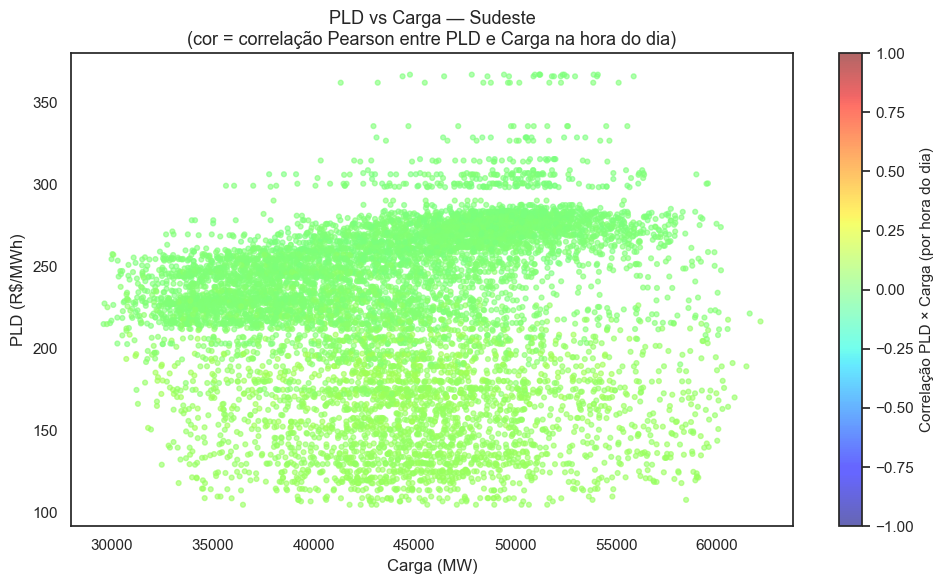


📊 Correlação PLD × Carga por hora:
 HORA  corr_PLD_Carga
    0        0.013050
    1        0.004647
    2        0.012614
    3        0.013435
    4        0.014387
    5        0.020040
    6        0.039716
    7        0.035195
    8        0.086921
    9        0.058729
   10        0.074020
   11        0.073974
   12        0.063369
   13        0.060846
   14        0.059250
   15        0.020431
   16        0.019119
   17        0.021801
   18       -0.003629
   19        0.005426
   20        0.010772
   21        0.013379
   22        0.013471
   23       -0.002896


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filtrar Sudeste
df_se = df[df['SUBMERCADO'] == 'SUDESTE'].copy()

# 2. Agregar: média de Carga e PLD por Data+HORA (elimina duplicatas de MES_REFERENCIA)
df_se = (
    df_se.groupby(['Data', 'HORA'], as_index=False)
    [['Carga', 'PLD_HORA']]
    .mean()
)

# 3. Correlação PLD x Carga por hora do dia
corr_por_hora = (
    df_se.groupby('HORA')
    .apply(lambda g: g['Carga'].corr(g['PLD_HORA']), include_groups=False)
    .reset_index()
    .rename(columns={0: 'corr_PLD_Carga'})
)

# 4. Merge
df_plot = df_se.merge(corr_por_hora, on='HORA')

# 5. Plot
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    df_plot['Carga'],
    df_plot['PLD_HORA'],
    c=df_plot['corr_PLD_Carga'],
    cmap="jet",
    alpha=0.6,
    s=12,
    vmin=-1, vmax=1
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Correlação PLD × Carga (por hora do dia)', fontsize=11)

ax.set_xlabel('Carga (MW)', fontsize=12)
ax.set_ylabel('PLD (R$/MWh)', fontsize=12)
ax.set_title('PLD vs Carga — Sudeste\n(cor = correlação Pearson entre PLD e Carga na hora do dia)', fontsize=13)

plt.tight_layout()
#plt.savefig('figuras/Correlação PLD × Carga (por hora do dia).png')
plt.show()

# 6. Tabela auxiliar
print("\n📊 Correlação PLD × Carga por hora:")
print(corr_por_hora.sort_values('HORA').to_string(index=False))

<span style="color:blue">A análise da correlação entre PLD e Carga para o submercado Sudeste, representada pelo gráfico de dispersão, evidencia a natureza complexa da formação de preços no SIN. A tentativa de mapear essa relação revela que, embora exista uma tendência de crescimento do preço frente ao aumento da demanda, essa conexão não é determinística. A alta dispersão dos dados indica que o custo marginal é fortemente influenciado por variáveis exógenas (disponibilidade renovável e níveis hidrológicos). A inclusão da correlação de Pearson horária via escala cromática permite observar que a sensibilidade do PLD à carga é variável ao longo do ciclo diário, sendo mais acentuada em períodos de rampa de consumo, onde o sistema opera próximo aos seus limites de despacho.
</span>

### <span style="color:blue">6.2. A Dinâmica Carga-Preço no Sudeste</span>


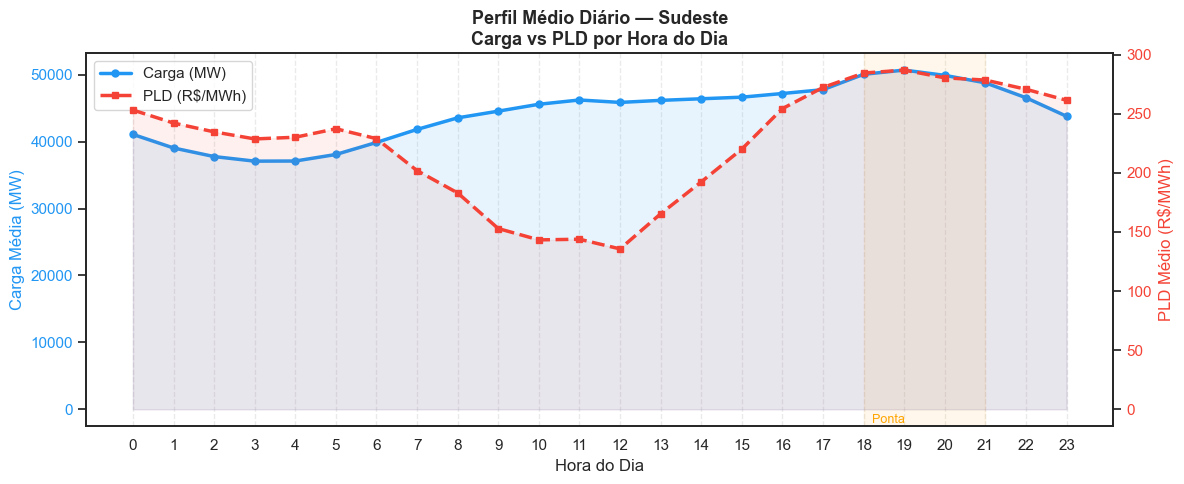

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 1. Filtrar e agregar
df_se = df[df['SUBMERCADO'] == 'SUDESTE'].copy()

df_hora = (
    df_se.groupby('HORA', as_index=False)
    [['Carga', 'PLD_HORA']]
    .mean()
    .sort_values('HORA')
)

# 2. Figura com dois eixos Y
fig, ax1 = plt.subplots(figsize=(12, 5))

# --- Carga (eixo esquerdo) ---
cor_carga = '#2196F3'
ax1.plot(df_hora['HORA'], df_hora['Carga'], color=cor_carga, linewidth=2.5, marker='o', markersize=5, label='Carga (MW)')
ax1.fill_between(df_hora['HORA'], df_hora['Carga'], alpha=0.10, color=cor_carga)
ax1.set_xlabel('Hora do Dia', fontsize=12)
ax1.set_ylabel('Carga Média (MW)', fontsize=12, color=cor_carga)
ax1.tick_params(axis='y', labelcolor=cor_carga)
ax1.set_xticks(range(0, 24))

# --- PLD (eixo direito) ---
cor_pld = '#F44336'
ax2 = ax1.twinx()
ax2.plot(df_hora['HORA'], df_hora['PLD_HORA'], color=cor_pld, linewidth=2.5, marker='s', markersize=5, linestyle='--', label='PLD (R$/MWh)')
ax2.fill_between(df_hora['HORA'], df_hora['PLD_HORA'], alpha=0.08, color=cor_pld)
ax2.set_ylabel('PLD Médio (R$/MWh)', fontsize=12, color=cor_pld)
ax2.tick_params(axis='y', labelcolor=cor_pld)

# --- Legenda unificada ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

# --- Destaque horário de ponta (18h-21h) ---
ax1.axvspan(18, 21, alpha=0.08, color='orange', label='Ponta')
ax1.text(18.2, ax1.get_ylim()[0], 'Ponta', fontsize=9, color='orange', va='bottom')

ax1.set_title('Perfil Médio Diário — Sudeste\nCarga vs PLD por Hora do Dia', fontsize=13, fontweight='bold')
ax1.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
#plt.savefig('figuras/Perfil Médio Diário — Sudeste e Carga vs PLD por Hora do Dia.png')
plt.show()

<span style="color:blue">A análise do perfil médio diário para o submercado Sudeste revela o impacto da transição energética na formação de preços. Observa-se uma correlação inversa entre carga e preço durante o período diurno (08h-14h), onde a abundância de geração solar reduz o custo marginal de operação, apesar do crescimento da demanda. Em contrapartida, o período de Ponta (18h-21h) consolida-se como o maior desafio sistêmico, apresentando a convergência entre o pico de carga e o ápice do PLD. Esse comportamento bimodal do preço exige que os agentes de mercado considerem não apenas o volume de energia, mas o valor temporal do consumo, evidenciando que a energia mais barata do dia coincide com o horário de maior oferta solar, e não com o de menor consumo.</span>


## 7. Conclusão e Próximos Passos (T2)  

### 7.1. Síntese dos Achados (T1)
<span style="color:blue">

A fase inicial deste estudo permitiu compreender a complexidade da formação de preços e do comportamento da carga no Sistema Interligado Nacional (SIN). Os principais pontos concluídos foram:
* **Descolamento entre Carga e Preço**: Identificamos que a relação entre demanda e PLD não é linear. O fenômeno da do PLD diário no Sudeste, impulsionado pela inserção de geração solar, demonstrou que o preço pode cair mesmo quando a carga aumenta, desafiando modelos simplistas de oferta e demanda.
* **Heterogeneidade Regional**: O subsistema Sudeste/Centro-Oeste não apenas domina em volume, mas também atua como o principal balizador da volatilidade. Enquanto isso, as regiões Norte e Nordeste apresentam perfis de carga mais estáveis, mas são fundamentais na transmissão de preços quando os limites de intercâmbio são atingidos.
* **Assimetria e Volatilidade**: A análise estatística revelou que o PLD opera sob um regime de bimodalidade (frequência no piso vs. picos extremos), enquanto a carga apresenta uma distribuição mais previsível, porém sujeita a sazonalidades climáticas e horárias marcantes.</span>


 ### Proposta para o Trabalho 2 (T2) - Machine Learning
<span style="color:blue">
Com base na robustez do dataset unificado (35.040 registros), os dados do T1 fornecem uma base sólida para a aplicação de algoritmos de Machine Learning. Para a próxima etapa, propomos as seguintes frentes:

**A. Modelagem Preditiva (Regressão)**
Utilizar modelos de séries temporais ou algoritmos de regressão (como Random Forest Regressor ou XGBoost) para prever o PLD horário.
**B. Classificação de Estresse Sistêmico**
Desenvolver um modelo de classificação para identificar estados de operação do sistema (ex: "Operação em Piso", "Risco de Ponta", "Estresse Térmico"). Isso permitiria prever com qual probabilidade o PLD atingirá valores acima de um determinado gatilho (ex: > R$ 500/MWh) com base no perfil de carga atual.
**C. Detecção de Anomalias**
Implementar técnicas de aprendizado não supervisionado para identificar desvios de carga que fogem ao padrão histórico (como feriados atípicos ou ondas de calor severas), avaliando o impacto financeiro imediato desses eventos no mercado de curto prazo.</span>


### 7.3. Considerações sobre Variáveis Exógenas
<span style="color:blue">
Reconhecemos que a precisão de um modelo de Machine Learning para o setor elétrico depende da inclusão de dados extra-dataset, como níveis de reservatórios (EAR) e previsões meteorológicas. No T2, buscaremos integrar métricas de "Energia Natural Afluente" (ENA) para reduzir o ruído estatístico observado nos gráficos de dispersão do T1, elevando a acurácia das previsões.</span>


### 8. Referências
<span style="color:blue">

#### Documentação Técnica e Bibliotecas
* Conda (Cheat Sheet e Comandos): https://docs.conda.io/projects/conda/en/latest/user-guide/cheatsheet.html
* Matplotlib (API Reference): https://matplotlib.org/stable/api/index.html
* NumPy (Manual de Referência): https://numpy.org/doc/stable/reference/index.html
* Pandas (API Reference): https://pandas.pydata.org/docs/reference/index.html
#### Bases de Dados e Fontes Oficiais
* ONS (Operador Nacional do Sistema Elétrico): Curva de carga horária 2025. Disponível em: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/curva-carga-ho/CURVA_CARGA_2025.xlsx
* CCEE (Câmara de Comercialização de Energia Elétrica): PLD Horário 2025. Disponível em: https://dadosabertos.ccee.org.br/dataset/pld_horario
</span>